# H₂ Yield Prediction from Dark Fermentation Process Parameters

## Notebook 02: Group-Wise Statistical Characterization

Per-group stats on six F/M ratios (0.5–3.0) — benchmarks for validating 1,000-obs synthetic datasets.

## 1. Import Required Libraries

Data handling, statistics, and plotting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## 2. Load the Quality-Controlled Reference Dataset

QC reference from audit; five high-confidence anomalies removed, genuine variability retained.

In [2]:
file_path = (
    r"D:\Data Science Projects\Hydrogen yield predictor"
    r"\data\processed\reference_experimental_data.csv"
)

df = pd.read_csv(file_path)

print("Reference dataset loaded successfully.")
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

df.head()

Reference dataset loaded successfully.
Number of observations: 61
Number of variables: 27


,treatment,substrate_mc,substrate_ts,substrate_vs,substrate_fs,inoculum_mc,inoculum_ts,inoculum_vs,inoculum_fs,scod,tcod,scod_tcod_ratio,trs,lignin,hmf,fm_ratio,h2_yield,substrate_mc_ts_sum,substrate_vs_fs_sum,inoculum_mc_ts_sum,inoculum_vs_fs_sum,calculated_scod_tcod_ratio,ratio_difference,data_quality_flag,quality_flags,outlier_variables,high_confidence_anomaly
0,1,5.210,94.790,89.220,10.780,90.110,9.890,90.110,9.890,6000,11500,0.520,1.440,25.420,42.550,0.500,22.220,100.000,100.000,100.000,100.000,0.522,0.002,valid,valid,none,False
1,2,5.640,94.360,87.230,12.770,92.330,7.670,86.400,13.600,6400,12000,0.530,6.820,23.210,689.490,0.500,20.400,100.000,100.000,100.000,100.000,0.533,0.003,valid,valid,none,False
2,3,5.610,94.390,88.260,11.740,95.120,4.880,87.260,12.740,5800,8900,0.650,5.740,23.000,425.190,0.500,26.450,100.000,100.000,100.000,100.000,0.652,0.002,valid,valid,none,False
3,4,5.260,94.740,78.640,21.360,94.700,5.300,92.330,7.670,5800,9000,0.640,22.160,28.910,189.350,0.500,24.220,100.000,100.000,100.000,100.000,0.644,0.004,valid,valid,none,False
4,5,5.940,94.060,78.410,21.590,93.780,6.220,84.770,15.230,6000,11200,0.540,22.200,20.230,0.000,0.500,19.650,100.000,100.000,100.000,100.000,0.536,0.004,valid,valid,none,False


## 3. Select Experimental Variables for Statistical Characterization

Keep only original process variables (not audit diagnostics); Treatment ID for traceability only.

In [3]:
experimental_columns = [
    "substrate_mc",
    "substrate_ts",
    "substrate_vs",
    "substrate_fs",
    "inoculum_mc",
    "inoculum_ts",
    "inoculum_vs",
    "inoculum_fs",
    "scod",
    "tcod",
    "scod_tcod_ratio",
    "trs",
    "lignin",
    "hmf",
    "fm_ratio",
    "h2_yield"
]

experimental_df = df[experimental_columns].copy()

print("Experimental dataset shape:")
print(experimental_df.shape)

experimental_df.head()

Experimental dataset shape:
(61, 16)


,substrate_mc,substrate_ts,substrate_vs,substrate_fs,inoculum_mc,inoculum_ts,inoculum_vs,inoculum_fs,scod,tcod,scod_tcod_ratio,trs,lignin,hmf,fm_ratio,h2_yield
0,5.210,94.790,89.220,10.780,90.110,9.890,90.110,9.890,6000,11500,0.520,1.440,25.420,42.550,0.500,22.220
1,5.640,94.360,87.230,12.770,92.330,7.670,86.400,13.600,6400,12000,0.530,6.820,23.210,689.490,0.500,20.400
2,5.610,94.390,88.260,11.740,95.120,4.880,87.260,12.740,5800,8900,0.650,5.740,23.000,425.190,0.500,26.450
3,5.260,94.740,78.640,21.360,94.700,5.300,92.330,7.670,5800,9000,0.640,22.160,28.910,189.350,0.500,24.220
4,5.940,94.060,78.410,21.590,93.780,6.220,84.770,15.230,6000,11200,0.540,22.200,20.230,0.000,0.500,19.650


## 4. Verify the F/M Group Structure

Confirm obs counts per F/M ratio — slight differences from QC drops; profiles become synthetic benchmarks.

In [4]:
fm_group_size = (
    experimental_df
    .groupby("fm_ratio")
    .size()
    .reset_index(name="observations")
)

fm_group_size

,fm_ratio,observations
0,0.500,11
1,1.000,11
2,1.500,9
3,2.000,10
4,2.500,10
5,3.000,10


## 5. Define Variables for Statistical Analysis

F/M groups the data; all other process parameters (incl. H₂ yield) analyzed per group for synthetic validation.

In [5]:
statistical_columns = [
    "substrate_mc",
    "substrate_ts",
    "substrate_vs",
    "substrate_fs",
    "inoculum_mc",
    "inoculum_ts",
    "inoculum_vs",
    "inoculum_fs",
    "scod",
    "tcod",
    "scod_tcod_ratio",
    "trs",
    "lignin",
    "hmf",
    "h2_yield"
]

print(
    f"Number of variables selected for statistical analysis: "
    f"{len(statistical_columns)}"
)

Number of variables selected for statistical analysis: 15


## 6. Group-Wise Descriptive Statistical Analysis

Per variable × F/M: n, mean, std, min/Q1/median/Q3/max — center, spread, and range benchmarks.

In [6]:
group_descriptive_stats = (
    experimental_df
    .groupby("fm_ratio")[statistical_columns]
    .describe()
)

group_descriptive_stats

substrate_mc                                           substrate_ts  \
                count  mean   std   min   25%   50%   75%   max        count   
fm_ratio                                                                       
0.500          11.000 5.725 0.418 5.000 5.435 5.870 5.995 6.230       11.000   
1.000          11.000 5.845 0.290 5.220 5.735 5.920 6.055 6.160       11.000   
1.500           9.000 6.376 0.559 5.440 6.130 6.310 6.490 7.350        9.000   
2.000          10.000 6.576 0.848 5.580 5.947 6.485 7.000 8.130       10.000   
2.500          10.000 6.430 0.830 5.010 6.175 6.440 6.862 8.000       10.000   
3.000          10.000 6.155 1.046 5.000 5.205 6.015 6.900 8.110       10.000   

                                                         substrate_vs         \
           mean   std    min    25%    50%    75%    max        count   mean   
fm_ratio                                                                       
0.500    94.275 0.418 93.770 94.005 94.130 94.565 95.000       11.000 83.065   
1.000    94.155 0.290 93.840 93.945 94.080 94.265 94.780       11.000 83.965   
1.500    93.624 0.559 92.650 93.510 93.690 93.870 94.560        9.000 86.598   
2.000    93.424 0.848 91.870 93.000 93.515 94.052 94.420       10.000 88.637   
2.500    93.570 0.830 92.000 93.138 93.560 93.825 94.990       10.000 89.226   
3.000    93.845 1.046 91.890 93.100 93.985 94.795 95.000       10.000 88.763   

                                                  substrate_fs               \
           std    min    25%    50%    75%    max        count   mean   std   
fm_ratio                                                                      
0.500    4.305 76.590 79.095 83.800 86.110 89.220       11.000 16.935 4.305   
1.000    3.820 77.420 82.770 83.240 86.000 91.220       11.000 16.035 3.820   
1.500    4.847 76.250 85.530 89.260 89.920 90.610        9.000 13.402 4.847   
2.000    2.902 83.330 88.015 88.630 90.705 92.670       10.000 11.363 2.902   
2.500    2.213 86.450 87.648 88.835 89.915 93.660       10.000 10.774 2.213   
3.000    2.216 83.360 87.905 89.250 90.153 91.110       10.000 11.237 2.216   

                                            inoculum_mc                      \
            min    25%    50%    75%    max       count   mean   std    min   
fm_ratio                                                                      
0.500    10.780 13.890 16.200 20.905 23.410      11.000 91.094 2.730 87.410   
1.000     8.780 14.000 16.760 17.230 22.580      11.000 88.850 2.656 84.660   
1.500     9.390 10.080 10.740 14.470 23.750       9.000 89.392 1.827 86.430   
2.000     7.330  9.295 11.370 11.985 16.670      10.000 89.624 2.238 86.330   
2.500     6.340 10.085 11.165 12.353 13.550      10.000 88.489 1.081 86.440   
3.000     8.890  9.848 10.750 12.095 16.640      10.000 86.975 3.331 79.250   

                                     inoculum_ts                            \
            25%    50%    75%    max       count   mean   std   min    25%   
fm_ratio                                                                     
0.500    89.085 90.900 93.055 95.120      11.000  8.906 2.730 4.880  6.945   
1.000    87.085 89.170 90.675 92.650      11.000 11.150 2.656 7.350  9.325   
1.500    88.420 90.090 90.240 91.320       9.000 10.608 1.827 8.680  9.760   
2.000    88.095 90.255 91.090 92.630      10.000 10.376 2.238 7.370  8.910   
2.500    87.767 88.605 89.315 90.010      10.000 11.511 1.081 9.990 10.685   
3.000    86.200 87.435 89.263 90.330      10.000 13.025 3.331 9.670 10.737   

                              inoculum_vs                                    \
            50%    75%    max       count   mean   std    min    25%    50%   
fm_ratio                                                                      
0.500     9.100 10.915 12.590      11.000 89.384 2.636 84.770 87.425 90.110   
1.000    10.830 12.915 15.340      11.000 88.391 2.431 84.150 86.925 88.210   
1.500     9.910 11.580 13.570       9.000 89.

## 7. Characterize H₂ Yield Across F/M Ratios

Target variable stats by F/M — verify synthetic data preserves F/M-specific yield behavior.

In [7]:
h2_group_statistics = (
    experimental_df
    .groupby("fm_ratio")["h2_yield"]
    .describe()
)

h2_group_statistics

,count,mean,std,min,25%,50%,75%,max
fm_ratio,,,,,,,,
0.500,11.000,19.526,7.189,0.000,19.660,21.150,23.260,26.450
1.000,11.000,82.040,15.557,63.800,65.725,86.630,89.425,112.360
1.500,9.000,122.931,22.958,92.590,108.640,110.650,137.450,163.200
2.000,10.000,372.909,114.788,106.230,341.280,396.775,417.683,554.890
2.500,10.000,272.271,48.677,201.120,228.132,286.035,301.738,336.510
3.000,10.000,167.329,59.004,36.330,164.752,173.045,199.752,244.420


### Interpretation of H₂ Yield Distribution

Peak ~373 mL/g VS at F/M 2.0; non-linear response with high spread at 2.0/3.0 — preserve in synthetic data.

## 8. Visualize the F/M-Specific H₂ Yield Distribution

Box plots + points by F/M — median/IQR and within-group spread for non-linear H₂ response.

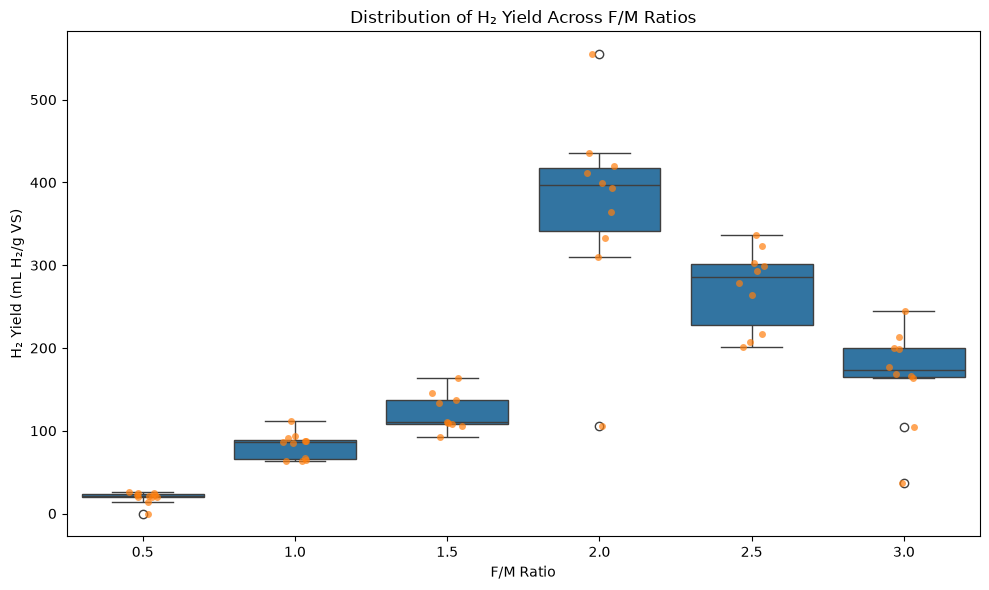

In [8]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=experimental_df,
    x="fm_ratio",
    y="h2_yield"
)

sns.stripplot(
    data=experimental_df,
    x="fm_ratio",
    y="h2_yield",
    jitter=True,
    alpha=0.7
)

plt.xlabel("F/M Ratio")
plt.ylabel("H₂ Yield (mL H₂/g VS)")
plt.title("Distribution of H₂ Yield Across F/M Ratios")

plt.tight_layout()
plt.show()

## 9. Evaluate Group-Wise Relative Variability

CV = (std/mean) × 100% by variable and F/M — relative spread across scales.

In [9]:
group_means = (
    experimental_df
    .groupby("fm_ratio")[statistical_columns]
    .mean()
)

group_std = (
    experimental_df
    .groupby("fm_ratio")[statistical_columns]
    .std()
)

group_cv = (
    group_std / group_means.abs()
) * 100

group_cv

,substrate_mc,substrate_ts,substrate_vs,substrate_fs,inoculum_mc,inoculum_ts,inoculum_vs,inoculum_fs,scod,tcod,scod_tcod_ratio,trs,lignin,hmf,h2_yield
fm_ratio,,,,,,,,,,,,,,,
0.500,7.309,0.444,5.182,25.420,2.997,30.655,2.949,24.827,23.674,24.896,16.421,93.037,18.026,93.520,36.816
1.000,4.970,0.309,4.550,23.824,2.989,23.820,2.750,20.940,13.889,17.789,26.409,47.388,19.605,57.807,18.963
1.500,8.770,0.597,5.597,36.162,2.044,17.223,1.302,11.019,13.236,11.166,15.497,27.537,39.455,58.000,18.675
2.000,12.901,0.908,3.274,25.536,2.497,21.571,3.392,24.997,13.667,10.837,18.589,23.186,45.655,102.724,30.782
2.500,12.904,0.887,2.480,20.539,1.222,9.394,3.764,27.144,13.090,19.273,25.826,76.020,43.251,64.718,17.878
3.000,17.002,1.115,2.496,19.718,3.830,25.576,2.326,19.623,12.767,14.248,11.206,25.264,39.545,85.909,35.262


In [10]:
h2_cv = group_cv[["h2_yield"]].copy()

h2_cv = h2_cv.rename(
    columns={"h2_yield": "h2_yield_cv_percent"}
)

h2_cv

,h2_yield_cv_percent
fm_ratio,
0.500,36.816
1.000,18.963
1.500,18.675
2.000,30.782
2.500,17.878
3.000,35.262


## 10. Evaluate Distribution Shape Using Skewness and Kurtosis

Skewness (asymmetry) and kurtosis (tail weight) per variable × F/M for synthetic comparison.

In [11]:
group_skewness = (
    experimental_df
    .groupby("fm_ratio")[statistical_columns]
    .skew()
)

group_kurtosis = (
    experimental_df
    .groupby("fm_ratio")[statistical_columns]
    .apply(lambda x: x.kurt())
)

print("Group-wise skewness:")
display(group_skewness)

print("\nGroup-wise kurtosis:")
display(group_kurtosis)

Group-wise skewness:


,substrate_mc,substrate_ts,substrate_vs,substrate_fs,inoculum_mc,inoculum_ts,inoculum_vs,inoculum_fs,scod,tcod,scod_tcod_ratio,trs,lignin,hmf,h2_yield
fm_ratio,,,,,,,,,,,,,,,
0.500,-0.521,0.521,-0.070,0.070,0.115,-0.115,-0.297,0.297,1.867,0.885,0.270,0.835,0.571,0.644,-2.299
1.000,-1.202,1.202,0.226,-0.226,-0.053,0.053,-0.226,0.226,0.259,0.365,1.733,0.007,-0.317,0.644,0.313
1.500,0.305,-0.305,-1.468,1.468,-0.862,0.862,-0.076,0.076,1.265,0.569,1.105,0.129,-0.638,0.987,0.541
2.000,0.681,-0.681,-0.679,0.679,-0.336,0.336,-0.813,0.813,1.609,0.163,0.867,0.209,0.665,1.334,-1.177
2.500,0.085,-0.085,0.908,-0.908,-0.563,0.563,-0.512,0.512,1.724,-1.946,1.553,1.747,0.747,1.363,-0.416
3.000,0.586,-0.586,-1.754,1.754,-1.461,1.461,1.863,-1.863,-1.198,-0.251,0.915,1.503,1.136,2.703,-1.270



Group-wise kurtosis:


,substrate_mc,substrate_ts,substrate_vs,substrate_fs,inoculum_mc,inoculum_ts,inoculum_vs,inoculum_fs,scod,tcod,scod_tcod_ratio,trs,lignin,hmf,h2_yield
fm_ratio,,,,,,,,,,,,,,,
0.500,-0.952,-0.952,-1.364,-1.364,-1.275,-1.275,-0.824,-0.824,3.037,1.230,-0.753,-0.587,-0.819,-0.286,6.089
1.000,0.834,0.834,0.434,0.434,-0.992,-0.992,-0.788,-0.788,1.897,-0.463,3.086,-1.582,-0.828,-0.326,-0.287
1.500,0.600,0.600,1.600,1.600,-0.649,-0.649,-1.111,-1.111,0.876,-0.278,1.732,0.206,-0.088,0.112,-0.724
2.000,-0.392,-0.392,0.008,0.008,-1.181,-1.181,1.394,1.394,3.333,-1.540,1.015,-0.120,-0.756,1.365,3.450
2.500,0.865,0.865,0.454,0.454,-0.109,-0.109,1.092,1.092,4.361,3.612,1.979,4.086,1.648,2.388,-1.297
3.000,-0.584,-0.584,3.816,3.816,2.576,2.576,5.220,5.220,4.089,-0.990,1.803,2.194,1.556,8.024,2.001


In [12]:
h2_distribution_shape = pd.DataFrame({
    "skewness": group_skewness["h2_yield"],
    "kurtosis": group_kurtosis["h2_yield"]
})

h2_distribution_shape

,skewness,kurtosis
fm_ratio,,
0.500,-2.299,6.089
1.000,0.313,-0.287
1.500,0.541,-0.724
2.000,-1.177,3.450
2.500,-0.416,-1.297
3.000,-1.270,2.001


### Interpretation of H₂ Yield Distribution Shape

Shape varies by F/M — don't assume one Gaussian. **Caveat:** n≈9–11/group makes skew/kurtosis unstable; use with distribution and multivariate checks.

In [13]:
correlation_matrix = experimental_df.corr()

correlation_matrix

,substrate_mc,substrate_ts,substrate_vs,substrate_fs,inoculum_mc,inoculum_ts,inoculum_vs,inoculum_fs,scod,tcod,scod_tcod_ratio,trs,lignin,hmf,fm_ratio,h2_yield
substrate_mc,1.000,-1.000,0.145,-0.145,-0.169,0.169,-0.191,0.191,0.135,-0.028,0.110,0.040,-0.356,-0.170,0.283,0.403
substrate_ts,-1.000,1.000,-0.145,0.145,0.169,-0.169,0.191,-0.191,-0.135,0.028,-0.110,-0.040,0.356,0.170,-0.283,-0.403
substrate_vs,0.145,-0.145,1.000,-1.000,-0.186,0.186,-0.063,0.063,0.041,-0.186,0.223,0.212,-0.501,-0.031,0.556,0.472
substrate_fs,-0.145,0.145,-1.000,1.000,0.186,-0.186,0.063,-0.063,-0.041,0.186,-0.223,-0.212,0.501,0.031,-0.556,-0.472
inoculum_mc,-0.169,0.169,-0.186,0.186,1.000,-1.000,-0.144,0.144,-0.188,-0.033,-0.115,-0.039,0.287,0.072,-0.401,-0.160
inoculum_ts,0.169,-0.169,0.186,-0.186,-1.000,1.000,0.144,-0.144,0.188,0.033,0.115,0.039,-0.287,-0.072,0.401,0.160
inoculum_vs,-0.191,0.191,-0.063,0.063,-0.144,0.144,1.000,-1.000,0.083,0.118,-0.048,0.028,0.026,0.337,-0.059,-0.331
inoculum_fs,0.191,-0.191,0.063,-0.063,0.144,-0.144,-1.000,1.000,-0.083,-0.118,0.048,-0.028,-0.026,-0.337,0.059,0.331
scod,0.135,-0.135,0.041,-0.041,-0.188,0.188,0.083,-0.083,1.000,0.439,0.380,-0.150,0.071,0.063,-0.065,-0.005
tcod,-0.028,0.028,-0.186,0.186,-0.033,0.033,0.118,-0.118,0.439,1.000,-0.626,-0.131,0.040,0.166,-0.205,-0.039


## 12. Visualize the Experimental Correlation Matrix

Heatmap of linear correlations — baseline multivariate structure for synthetic validation.

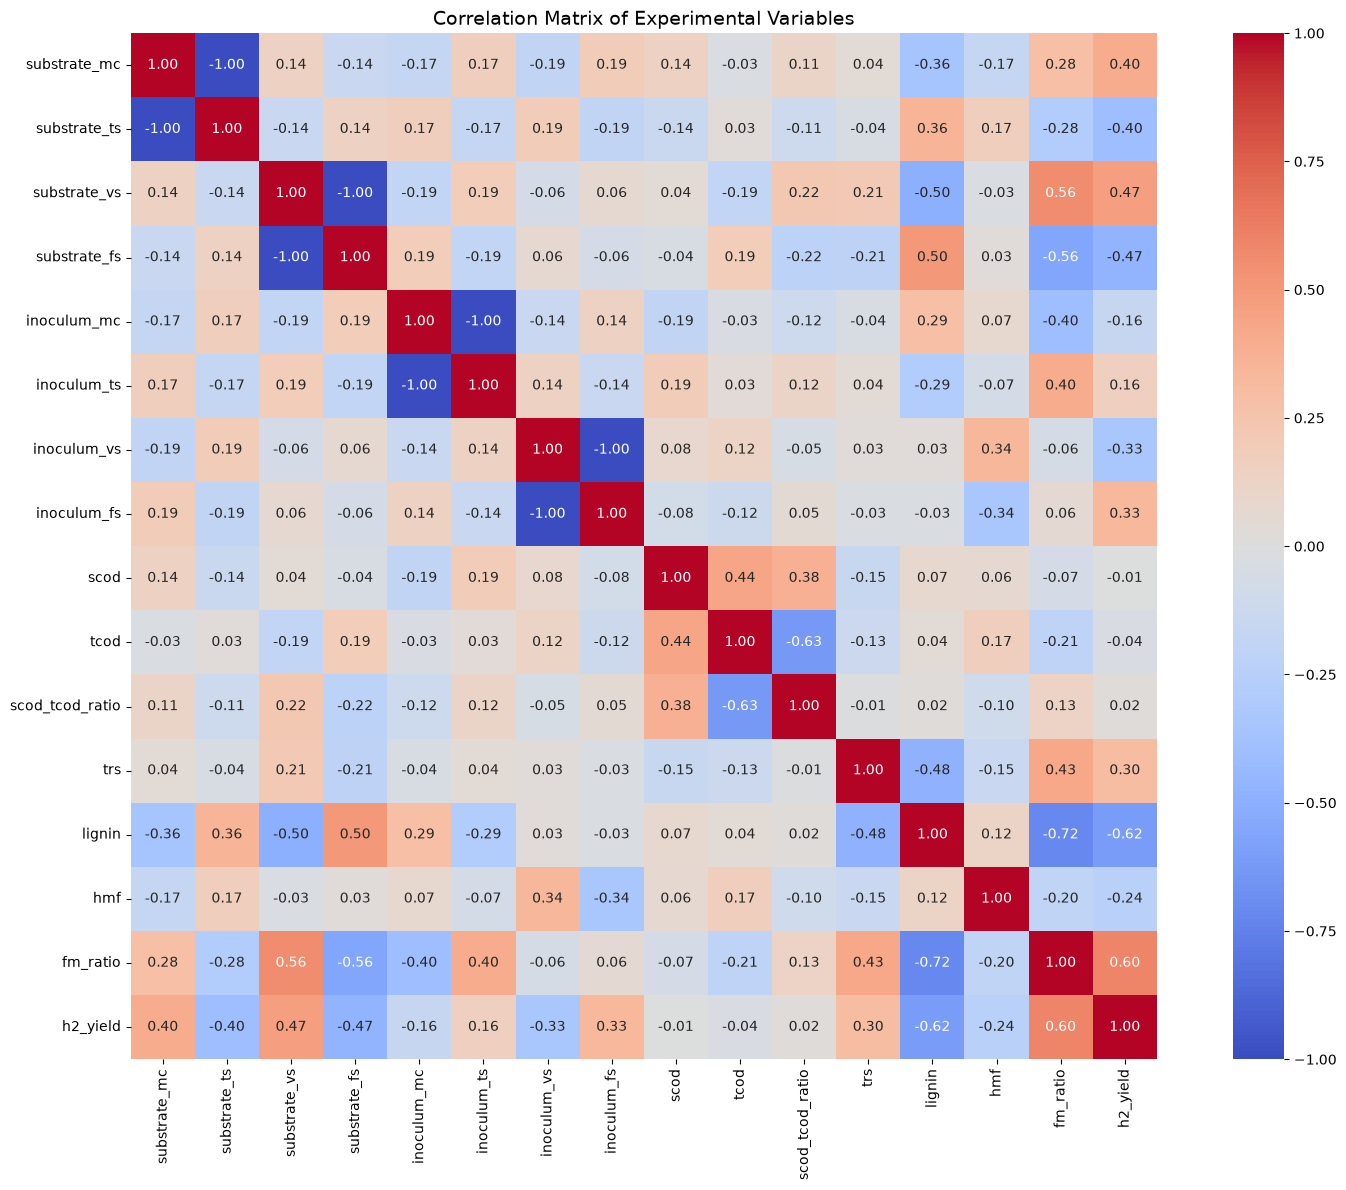

In [14]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Correlation Matrix of Experimental Variables",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 13. Examine Variable Associations with H₂ Yield

Rank correlations with H₂ yield — cross-check against model feature importance later.

In [15]:
h2_correlations = (
    correlation_matrix["h2_yield"]
    .drop("h2_yield")
    .sort_values(ascending=False)
    .to_frame(name="correlation_with_h2_yield")
)

h2_correlations

,correlation_with_h2_yield
fm_ratio,0.598
substrate_vs,0.472
substrate_mc,0.403
inoculum_fs,0.331
trs,0.304
inoculum_ts,0.160
scod_tcod_ratio,0.023
scod,-0.005
tcod,-0.039
inoculum_mc,-0.160


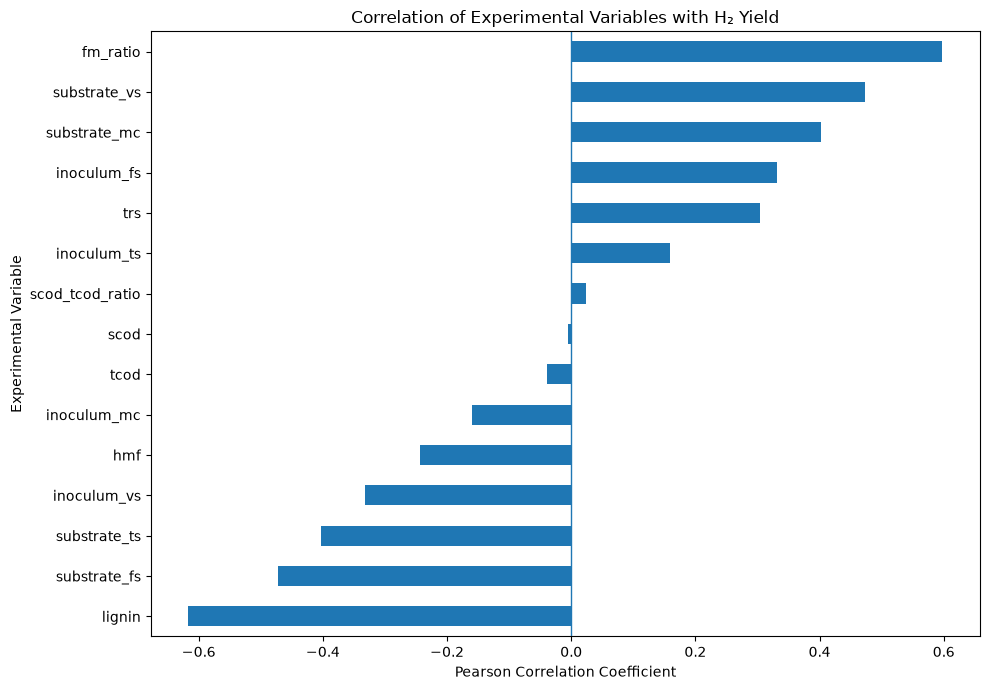

In [16]:
plt.figure(figsize=(10, 7))

h2_correlations[
    "correlation_with_h2_yield"
].sort_values().plot(kind="barh")

plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Experimental Variable")
plt.title("Correlation of Experimental Variables with H₂ Yield")

plt.axvline(
    x=0,
    linewidth=1
)

plt.tight_layout()
plt.show()

### Interpretation of Correlations with H₂ Yield

F/M strongest positive link; MC+TS and VS+FS pairs are redundant; Pearson understates non-linear F/M effect (peak at 2.0).

## 14. Evaluate Mathematically Dependent Experimental Variables

Check complementary/derived pairs (MC↔TS, VS↔FS, sCOD/TCOD) — document before synthetic generation and modeling.

In [17]:
dependent_pairs = [
    ("substrate_mc", "substrate_ts"),
    ("substrate_vs", "substrate_fs"),
    ("inoculum_mc", "inoculum_ts"),
    ("inoculum_vs", "inoculum_fs"),
]

dependency_results = []

for variable_1, variable_2 in dependent_pairs:
    
    correlation = experimental_df[
        [variable_1, variable_2]
    ].corr().iloc[0, 1]
    
    dependency_results.append({
        "variable_1": variable_1,
        "variable_2": variable_2,
        "correlation": correlation
    })

dependency_df = pd.DataFrame(dependency_results)

dependency_df

,variable_1,variable_2,correlation
0,substrate_mc,substrate_ts,-1.000
1,substrate_vs,substrate_fs,-1.000
2,inoculum_mc,inoculum_ts,-1.000
3,inoculum_vs,inoculum_fs,-1.000


## 15. Verify the Derived sCOD/TCOD Ratio

Compare reported vs. recalculated sCOD/TCOD — tight match confirms redundancy.

In [18]:
experimental_df["calculated_scod_tcod_ratio"] = (
    experimental_df["scod"] /
    experimental_df["tcod"]
)

ratio_correlation = experimental_df[
    [
        "scod_tcod_ratio",
        "calculated_scod_tcod_ratio"
    ]
].corr().iloc[0, 1]

print(
    "Correlation between reported and calculated "
    f"sCOD/TCOD ratio: {ratio_correlation:.4f}"
)

Correlation between reported and calculated sCOD/TCOD ratio: 0.9997


## 16. Evaluate F/M-Specific Correlations with H₂ Yield

Variable–H₂ correlations within each F/M group — associations may shift per ratio.

In [19]:
group_h2_correlations = {}

for fm_value, group in experimental_df.groupby("fm_ratio"):
    
    correlations = (
        group[statistical_columns]
        .corr()["h2_yield"]
        .drop("h2_yield")
        .sort_values(ascending=False)
    )
    
    group_h2_correlations[fm_value] = correlations

group_h2_correlation_df = pd.DataFrame(
    group_h2_correlations
)

group_h2_correlation_df.columns = [
    f"FM_{column}"
    for column in group_h2_correlation_df.columns
]

group_h2_correlation_df

,FM_0.5,FM_1.0,FM_1.5,FM_2.0,FM_2.5,FM_3.0
hmf,-0.634,-0.401,-0.025,-0.672,-0.460,0.176
inoculum_fs,0.454,-0.159,0.269,0.618,0.498,0.518
inoculum_mc,0.633,-0.113,-0.014,-0.603,-0.036,0.370
inoculum_ts,-0.633,0.113,0.014,0.603,0.036,-0.370
inoculum_vs,-0.454,0.159,-0.269,-0.618,-0.498,-0.518
lignin,0.436,0.080,-0.614,0.055,0.506,0.068
scod,-0.170,-0.349,-0.541,0.097,0.488,-0.223
scod_tcod_ratio,-0.024,-0.329,-0.449,0.197,-0.144,0.299
substrate_fs,-0.064,-0.152,-0.278,-0.123,-0.010,0.157
substrate_mc,-0.324,0.260,-0.569,0.310,0.531,-0.126


## 17. Visualize F/M-Specific Correlation Patterns

Heatmap of variable–H₂ correlations across F/M groups — stable vs. shifting relationships.

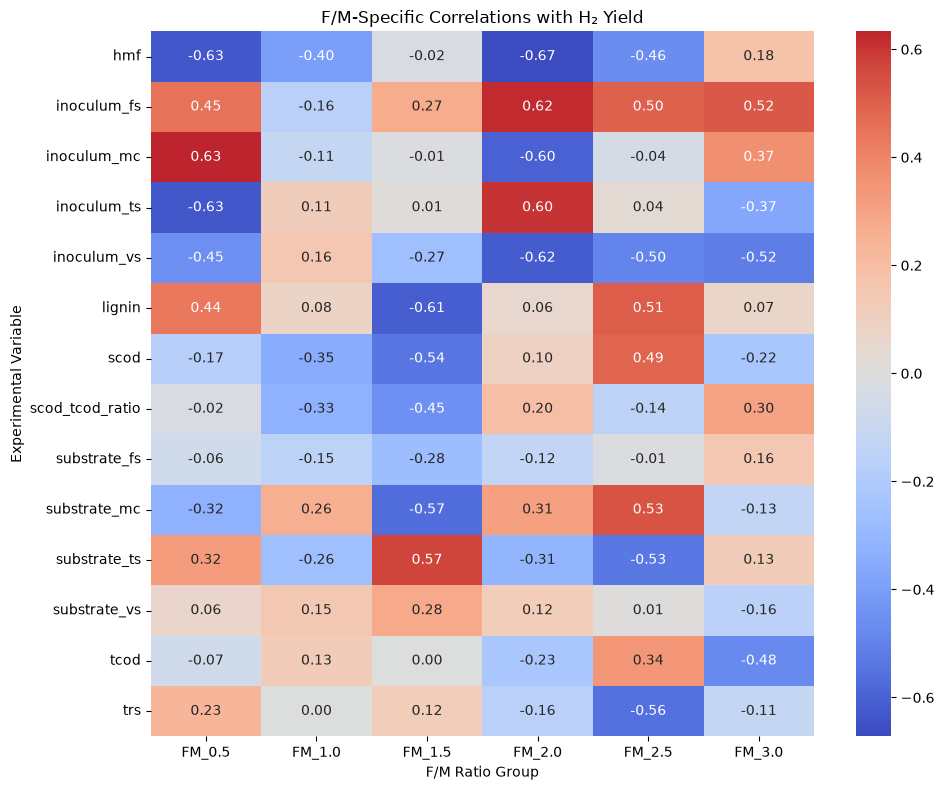

In [20]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    group_h2_correlation_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.xlabel("F/M Ratio Group")
plt.ylabel("Experimental Variable")

plt.title(
    "F/M-Specific Correlations with H₂ Yield"
)

plt.tight_layout()
plt.show()

### Interpretation of F/M-Specific Correlation Patterns

Correlations shift across F/M. **Caveat:** n≈9–11/group — noisy; pooled multivariate structure + F/M conditioning, validate group stats separately.

## 18. Evaluate Correlation Stability Across F/M Ratios

Per variable vs. H₂: correlation mean/std/min/max/range — wide ranges expected with n≈9–11, not changing causation.

In [21]:
correlation_stability = pd.DataFrame({
    "mean_correlation": group_h2_correlation_df.mean(axis=1),
    "std_correlation": group_h2_correlation_df.std(axis=1),
    "min_correlation": group_h2_correlation_df.min(axis=1),
    "max_correlation": group_h2_correlation_df.max(axis=1)
})

correlation_stability["correlation_range"] = (
    correlation_stability["max_correlation"]
    - correlation_stability["min_correlation"]
)

correlation_stability = (
    correlation_stability
    .sort_values(
        "correlation_range",
        ascending=False
    )
)

correlation_stability

,mean_correlation,std_correlation,min_correlation,max_correlation,correlation_range
inoculum_ts,-0.040,0.426,-0.633,0.603,1.236
inoculum_mc,0.040,0.426,-0.603,0.633,1.236
lignin,0.088,0.398,-0.614,0.506,1.120
substrate_ts,-0.014,0.422,-0.531,0.569,1.100
substrate_mc,0.014,0.422,-0.569,0.531,1.100
scod,-0.116,0.363,-0.541,0.488,1.029
hmf,-0.336,0.341,-0.672,0.176,0.848
tcod,-0.050,0.285,-0.478,0.345,0.823
trs,-0.079,0.276,-0.557,0.234,0.791
inoculum_fs,0.366,0.282,-0.159,0.618,0.777


## 19. Define Statistical Fidelity Benchmarks for Synthetic Data

Match statistical structure (not row-copy): group-level center/spread/shape; multivariate correlations; physical constraints (MC+TS≈100%, sCOD≤TCOD, etc.). Target: 6,000 rows (1,000×6 F/M).

## 20. Create the Group-Wise Statistical Benchmark Table

Variables × F/M — center, spread, shape; saved for experimental vs. synthetic comparison.

In [22]:
benchmark_records = []

for fm_value, group in experimental_df.groupby("fm_ratio"):
    
    for column in statistical_columns:
        
        series = group[column]
        
        benchmark_records.append({
            "fm_ratio": fm_value,
            "variable": column,
            "count": series.count(),
            "mean": series.mean(),
            "std": series.std(),
            "median": series.median(),
            "q1": series.quantile(0.25),
            "q3": series.quantile(0.75),
            "iqr": (
                series.quantile(0.75)
                - series.quantile(0.25)
            ),
            "min": series.min(),
            "max": series.max(),
            "cv_percent": (
                series.std() / abs(series.mean()) * 100
                if series.mean() != 0
                else np.nan
            ),
            "skewness": series.skew(),
            "kurtosis": series.kurt()
        })

statistical_benchmark = pd.DataFrame(
    benchmark_records
)

statistical_benchmark.head(15)

,fm_ratio,variable,count,mean,std,median,q1,q3,iqr,min,max,cv_percent,skewness,kurtosis
0,0.500,substrate_mc,11,5.725,0.418,5.870,5.435,5.995,0.560,5.000,6.230,7.309,-0.521,-0.952
1,0.500,substrate_ts,11,94.275,0.418,94.130,94.005,94.565,0.560,93.770,95.000,0.444,0.521,-0.952
2,0.500,substrate_vs,11,83.065,4.305,83.800,79.095,86.110,7.015,76.590,89.220,5.182,-0.070,-1.364
3,0.500,substrate_fs,11,16.935,4.305,16.200,13.890,20.905,7.015,10.780,23.410,25.420,0.070,-1.364
4,0.500,inoculum_mc,11,91.094,2.730,90.900,89.085,93.055,3.970,87.410,95.120,2.997,0.115,-1.275
5,0.500,inoculum_ts,11,8.906,2.730,9.100,6.945,10.915,3.970,4.880,12.590,30.655,-0.115,-1.275
6,0.500,inoculum_vs,11,89.384,2.636,90.110,87.425,91.115,3.690,84.770,93.210,2.949,-0.297,-0.824
7,0.500,inoculum_fs,11,10.616,2.636,9.890,8.885,12.575,3.690,6.790,15.230,24.827,0.297,-0.824
8,0.500,scod,11,6954.545,1646.429,6200.000,6000.000,7100.000,1100.000,5800.000,11000.000,23.674,1.867,3.037
9,0.500,tcod,11,13054.545,3250.035,12400.000,11350.000,14500.000,3150.000,8900.000,20200.000,24.896,0.885,1.230


## 21. Save the Statistical Benchmark Dataset

Write benchmark table for synthetic validation notebook.

In [23]:
benchmark_file = (
    r"D:\Data Science Projects\Hydrogen yield predictor"
    r"\data\processed\group_statistical_benchmarks.csv"
)

statistical_benchmark.to_csv(
    benchmark_file,
    index=False
)

print("Statistical benchmark saved successfully.")
print(benchmark_file)

Statistical benchmark saved successfully.
D:\Data Science Projects\Hydrogen yield predictor\data\group_statistical_benchmarks.csv
